Đang tính SHAP values...


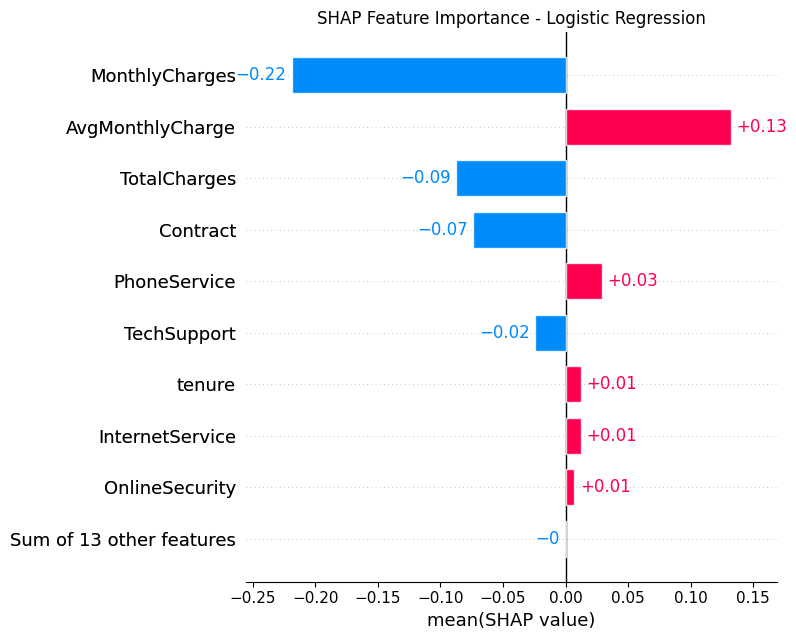

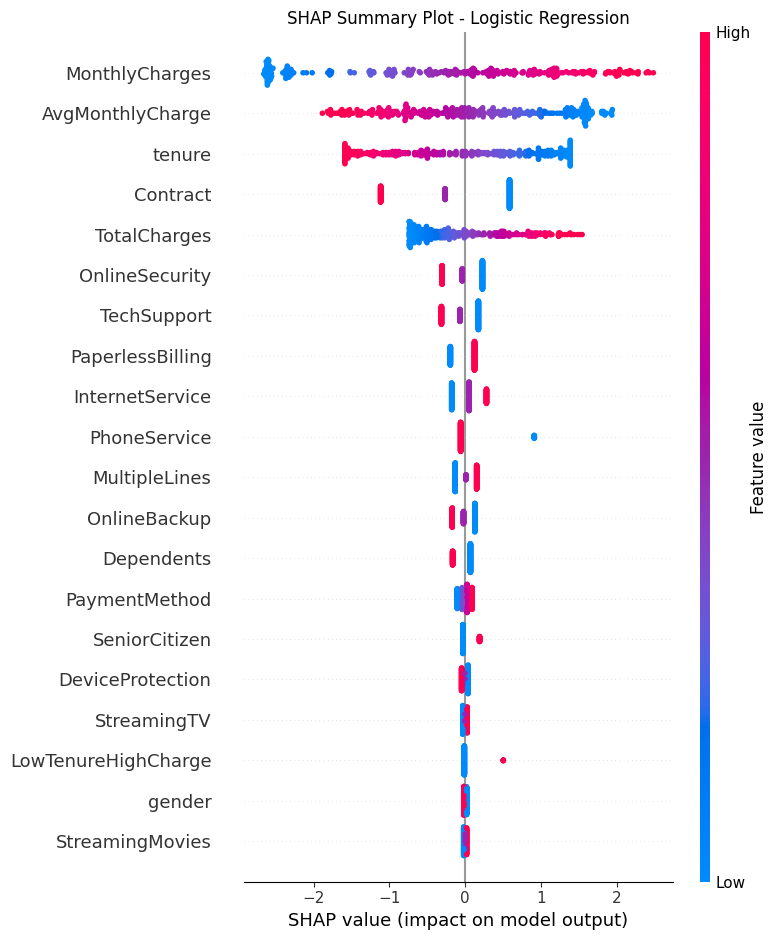


✅ SHAP Analysis HOÀN TẤT!


In [7]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression

# Đường dẫn
BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, 'data/')
FIGURE_PATH = os.path.join(BASE_DIR, 'reports/figures/')
os.makedirs(FIGURE_PATH, exist_ok=True)

# Load data
X_train = pd.read_csv(DATA_PATH + 'X_train.csv')
X_test = pd.read_csv(DATA_PATH + 'X_test.csv')
y_train = pd.read_csv(DATA_PATH + 'y_train.csv').squeeze()

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Đang tính SHAP values...")

# Sử dụng Explainer phù hợp
explainer = shap.Explainer(model, X_train, feature_names=X_train.columns.tolist())
test_sample = X_test.iloc[:300]

shap_values = explainer(test_sample)

# Fix cho binary classification
if len(shap_values.shape) == 3:   # Multi-class
    shap_values_plot = shap_values[:, :, 1]
else:   # Binary
    shap_values_plot = shap_values

# Plots
shap.plots.bar(shap_values_plot.mean(0), show=False)
plt.title("SHAP Feature Importance - Logistic Regression")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'shap_feature_importance.png'))
plt.show()

shap.summary_plot(shap_values_plot.values, test_sample, show=False)
plt.title("SHAP Summary Plot - Logistic Regression")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'shap_summary.png'))
plt.show()

print("\n✅ SHAP Analysis HOÀN TẤT!")

Đang train lại model để SHAP...
Đang tính SHAP values trên FULL test set...


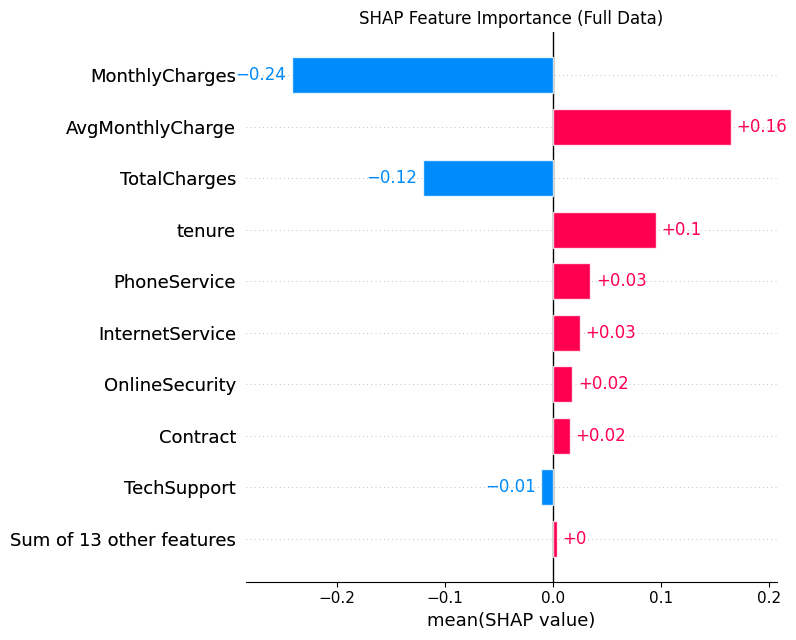

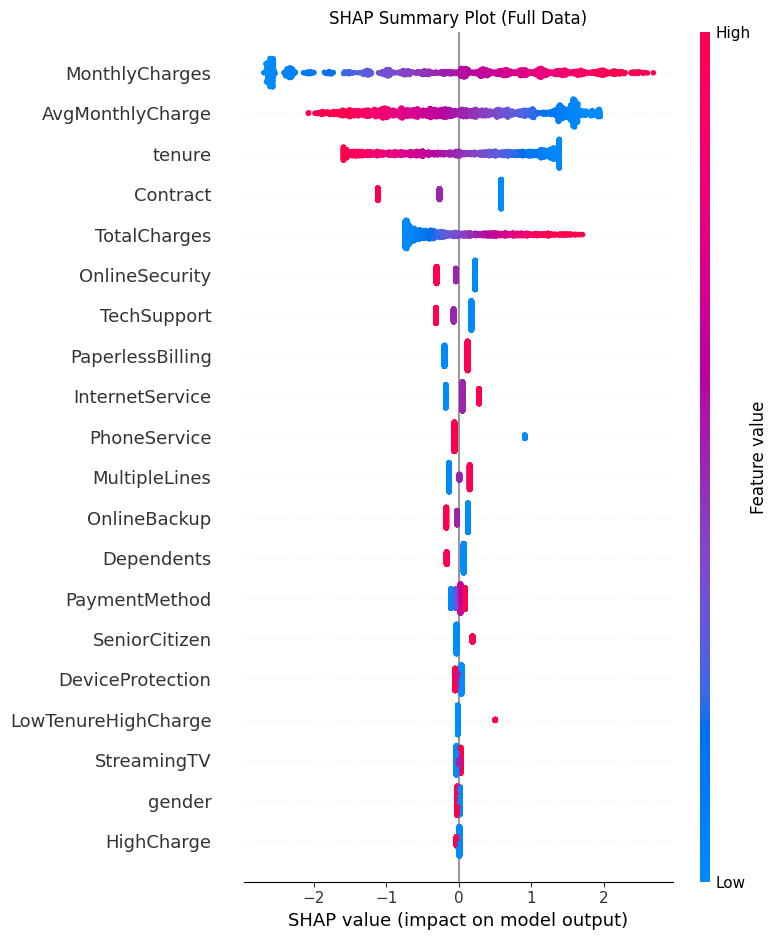


✅ SHAP Analysis trên FULL DATA hoàn tất!
2 file hình đã được lưu vào folder reports/figures/


In [8]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression

# ====================== 1. Đường dẫn ======================
BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, 'data/')
FIGURE_PATH = os.path.join(BASE_DIR, 'reports/figures/')
os.makedirs(FIGURE_PATH, exist_ok=True)

# ====================== 2. Load data & Model ======================
X_train = pd.read_csv(DATA_PATH + 'X_train.csv')
X_test = pd.read_csv(DATA_PATH + 'X_test.csv')
y_train = pd.read_csv(DATA_PATH + 'y_train.csv').squeeze()

print("Đang train lại model để SHAP...")
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ====================== 3. SHAP Explainer ======================
print("Đang tính SHAP values trên FULL test set...")

explainer = shap.Explainer(model, X_train, feature_names=X_train.columns.tolist())

# Full X_test (không sample)
shap_values = explainer(X_test)

# Xử lý output cho binary classification
if len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 1]   # Lớp Churn = 1
else:
    shap_values_plot = shap_values

# ====================== 4. Vẽ biểu đồ ======================
# Bar plot - Tầm quan trọng feature
shap.plots.bar(shap_values_plot.mean(0), show=False)
plt.title("SHAP Feature Importance (Full Data)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'shap_feature_importance_full.png'))
plt.show()

# Summary plot
shap.summary_plot(shap_values_plot.values, X_test, show=False)
plt.title("SHAP Summary Plot (Full Data)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'shap_summary_full.png'))
plt.show()

print("\n✅ SHAP Analysis trên FULL DATA hoàn tất!")
print("2 file hình đã được lưu vào folder reports/figures/")